In [1]:
import json
import re
from collections import defaultdict
import numpy as np
import os

def read_and_split_log_file(file_path):
    """
    Read a log file and split it into chunks wherever '}{' is found.
    The '}' goes to the previous chunk and '{' goes to the next chunk.
    """
    with open(file_path, 'r', encoding='utf-8') as file:
        content = file.read()
        content = content.lstrip('\ufeff')
    
    # Split the content by '}{' pattern
    # This will split at the boundary between JSON objects
    chunks = re.split(r'}{', content)
    
    # Process chunks to properly format them as complete JSON objects
    json_objects = []
    
    for i, chunk in enumerate(chunks):
        chunk = chunk.strip()
        if not chunk:
            continue
            
        # Add opening brace to all chunks except the first
        if i > 0:
            chunk = '{' + chunk
            
        # Add closing brace to all chunks except the last
        if i < len(chunks) - 1:
            chunk = chunk + '}'
        
        # Try to parse as JSON
        try:
            json_obj = json.loads(chunk)
            json_objects.append(json_obj)
        except json.JSONDecodeError as e:
            print(f"Failed to parse chunk {i}: {e}")
            print(f"Chunk content: {chunk[:100]}...")  # Show first 100 chars
        

    return json_objects

def extract_number_from_filename(filename):
    """Extract the number from filenames like '500_recorder.log'"""
    import re
    match = re.search(r'(\d+)_recorder\.log', filename)
    return int(match.group(1)) if match else 0


def prepare_dataset(data):
    """
    prepare the dataset from data which is a per game data, 
    get the features as a dictionary with (agent, [ agent_data ] ) where agent is not a bot 

    """
    # Group samples by game_id
    
    game_agents = defaultdict(list)

    for sample in data:
        game_id = sample["game_id"]
        for agent in sample["agents_data"]:
            if agent["isBot"] == False:
                key = f"{game_id}_{agent['agent_id']}"
                game_agents[key].append(agent)
    
    return game_agents


def convert_numpy(obj):
    if isinstance(obj, np.integer):
        return int(obj)
    elif isinstance(obj, np.floating):
        return float(obj)
    elif isinstance(obj, np.ndarray):
        return obj.tolist()
    return obj



In [2]:
import numpy as np
import matplotlib.pyplot as plt

# Initialize a large numpy array to store the bitmap
# The game coordinates seem to be in a large range, so let's create a reasonably sized array
# We'll scale down the coordinates to fit in this array
BITMAP_SIZE = 1000  # 1000x1000 bitmap
bitmap = np.zeros((BITMAP_SIZE, BITMAP_SIZE), dtype=np.uint8)

# Track min/max coordinates to help with scaling
min_x = float('inf')
max_x = float('-inf')
min_z = float('inf')
max_z = float('-inf')


In [3]:

# Define the folder path
import os
from tqdm import tqdm
folder_path = "/Users/vaibhavmishra/Downloads/clash_squad"
subfolders = [f.path for f in os.scandir(folder_path) if f.is_dir()]
print("Subfolders:", len(subfolders))


Subfolders: 2620


In [4]:
# Process all agent positions and create frequency map
from collections import defaultdict
position_freq = defaultdict(int)  # Dictionary to store position frequencies

# Process each game folder
for game_folder in tqdm(subfolders, desc="Processing game folders"):
    log_files = []
    full_game_folder_path = os.path.join(folder_path, os.path.basename(game_folder))
    
    # Find all log files in the game folder
    for root, dirs, files in os.walk(full_game_folder_path):
        for file in files:
            if file.endswith('.log'):
                complete_path = os.path.join(root, file)
                log_files.append(complete_path)
    
    # Process each log file
    for log_file in log_files:
        try:
            json_objects = read_and_split_log_file(log_file)
            
            # Process each game state
            for game_object in json_objects:
                if game_object.get('round_number', 0) == 0:
                    continue
                    
                # Process each agent's position
                for agent_data in game_object['agents_data']:
                    # Round coordinates to 1 decimal place
                    x_pos = round(agent_data['agentPosition']['x'], 1)
                    z_pos = round(agent_data['agentPosition']['z'], 1)
                    position_freq[(x_pos, z_pos)] += 1
                    
        except Exception as e:
            print(f"Error processing file {log_file}: {e}")
            continue

# Convert frequencies to numpy arrays for plotting
x_coords = [pos[0] for pos in position_freq.keys()]
z_coords = [pos[1] for pos in position_freq.keys()]
frequencies = list(position_freq.values())

print(f"Total unique positions: {len(position_freq)}")
print(f"X range: {min(x_coords):.1f} to {max(x_coords):.1f}")
print(f"Z range: {min(z_coords):.1f} to {max(z_coords):.1f}")
print(f"Frequency range: {min(frequencies)} to {max(frequencies)}")

# Create a 2D histogram using the original coordinates
plt.figure(figsize=(15, 15))
hist = plt.hist2d(x_coords, z_coords, weights=frequencies, bins=10, cmap='viridis')
plt.colorbar(hist[3], label='Visit Frequency')
plt.title('Agent Movement Heatmap (10 bins)')
plt.xlabel('X Coordinate')
plt.ylabel('Z Coordinate')
plt.savefig('clash_squad_agent_movement_heatmap.png', dpi=300, bbox_inches='tight')
plt.close()

# Create an interactive version with plotly
import plotly.graph_objects as go

fig = go.Figure(data=go.Histogram2d(
    x=x_coords,
    y=z_coords,
    z=frequencies,
    nbinsx=10,
    nbinsy=10,
    colorscale='Viridis',
))

fig.update_layout(
    title='Agent Movement Heatmap (Interactive, 10 bins)',
    xaxis_title='X Coordinate',
    yaxis_title='Z Coordinate'
)

fig.write_html("clash_squad_interactive_heatmap.html")


Processing game folders: 100%|██████████| 2620/2620 [34:04<00:00,  1.28it/s]


Total unique positions: 6351932
X range: -716.6 to 671.3
Z range: -662.3 to 874.0
Frequency range: 1 to 1222576


Frequency bin edges: [1.0000000e+00 1.2225850e+05 2.4451600e+05 3.6677350e+05 4.8903100e+05
 6.1128850e+05 7.3354600e+05 8.5580350e+05 9.7806100e+05 1.1003185e+06
 1.2225760e+06]
Bin 1: 1 - 122258 visits (6351908 positions)
Bin 2: 122258 - 244516 visits (13 positions)
Bin 3: 244516 - 366774 visits (4 positions)
Bin 4: 366774 - 489031 visits (3 positions)
Bin 5: 489031 - 611288 visits (2 positions)
Bin 6: 611288 - 733546 visits (0 positions)
Bin 7: 733546 - 855804 visits (1 positions)
Bin 8: 855804 - 978061 visits (0 positions)
Bin 9: 978061 - 1100318 visits (0 positions)
Bin 10: 1100318 - 1222576 visits (1 positions)


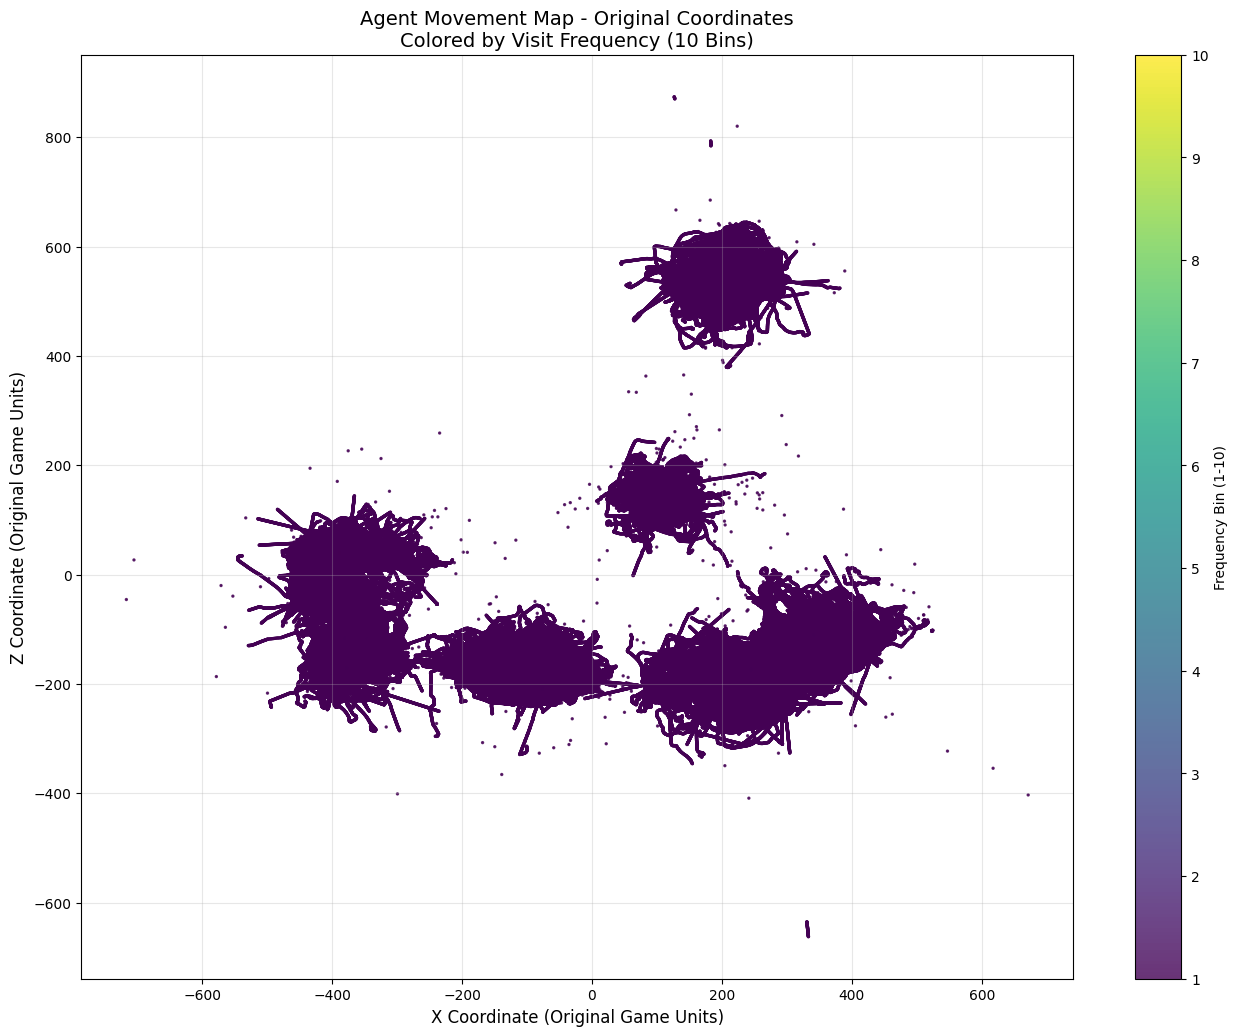

\nFiles saved:
- clash_squad_frequency_binned_heatmap.png (static image)
- clash_squad_frequency_binned_interactive.html (interactive)
\nCoordinate precision: 1 decimal place
Total unique positions: 6,351,932
Coordinate ranges: X(-716.6 to 671.3), Z(-662.3 to 874.0)


In [5]:
# Create frequency-based bins (10 bins) for visualization
import numpy as np
import pandas as pd

# Create 10 frequency bins
frequencies = list(position_freq.values())
min_freq = min(frequencies)
max_freq = max(frequencies)

# Create 10 equal-width bins for frequencies
freq_bins = np.linspace(min_freq, max_freq, 11)  # 11 edges for 10 bins
print("Frequency bin edges:", freq_bins)

# Assign each position to a frequency bin (1-10)
x_coords_binned = []
z_coords_binned = []
bin_assignments = []

for (x, z), freq in position_freq.items():
    # Find which bin this frequency belongs to
    bin_index = np.digitize(freq, freq_bins) - 1  # -1 because digitize returns 1-based index
    bin_index = min(bin_index, 9)  # Ensure we don't exceed bin 9 (for bin 10)
    
    x_coords_binned.append(x)
    z_coords_binned.append(z)
    bin_assignments.append(bin_index + 1)  # +1 to make bins 1-10 instead of 0-9

# Create scatter plot with frequency bins
plt.figure(figsize=(16, 12))
scatter = plt.scatter(x_coords_binned, z_coords_binned, c=bin_assignments, 
                     cmap='viridis', s=2, alpha=0.8)
cbar = plt.colorbar(scatter, label='Frequency Bin (1-10)', ticks=range(1, 11))
plt.title('Agent Movement Map - Original Coordinates\nColored by Visit Frequency (10 Bins)', fontsize=14)
plt.xlabel('X Coordinate (Original Game Units)', fontsize=12)
plt.ylabel('Z Coordinate (Original Game Units)', fontsize=12)
plt.grid(True, alpha=0.3)

# Add frequency range information for each bin
for i in range(10):
    bin_start = freq_bins[i]
    bin_end = freq_bins[i+1]
    count_in_bin = sum(1 for b in bin_assignments if b == i+1)
    print(f"Bin {i+1}: {bin_start:.0f} - {bin_end:.0f} visits ({count_in_bin} positions)")

plt.savefig('clash_squad_frequency_binned_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

# Create interactive plotly version with frequency bins
import plotly.express as px

df = pd.DataFrame({
    'X': x_coords_binned,
    'Z': z_coords_binned,
    'Frequency_Bin': bin_assignments,
    'Visit_Count': [position_freq[(x, z)] for x, z in zip(x_coords_binned, z_coords_binned)]
})

fig = px.scatter(df, x='X', y='Z', color='Frequency_Bin',
                 color_continuous_scale='Viridis',
                 hover_data=['Visit_Count'],
                 labels={'Frequency_Bin': 'Frequency Bin (1-10)', 
                        'X': 'X Coordinate', 
                        'Z': 'Z Coordinate',
                        'Visit_Count': 'Visit Count'},
                 title='Agent Movement Frequency Map - Interactive<br>Original Coordinates with 10 Frequency Bins')

fig.update_traces(marker=dict(size=4))
fig.update_coloraxes(colorbar_title="Frequency Bin", 
                    colorbar=dict(tickmode="linear", tick0=1, dtick=1))
fig.write_html("clash_squad_frequency_binned_interactive.html")

print("\\nFiles saved:")
print("- clash_squad_frequency_binned_heatmap.png (static image)")
print("- clash_squad_frequency_binned_interactive.html (interactive)")
print(f"\\nCoordinate precision: 1 decimal place")
print(f"Total unique positions: {len(position_freq):,}")
print(f"Coordinate ranges: X({min(x_coords_binned):.1f} to {max(x_coords_binned):.1f}), Z({min(z_coords_binned):.1f} to {max(z_coords_binned):.1f})")


In [6]:

# List to store complete paths of .log files
from tqdm import tqdm

for game_folder in tqdm(subfolders, desc="Processing game folders"):
    log_files = []
    # Walk through the directory and find all .log files
    # Combine folder_path and game_folder to get the full path to the game folder
    full_game_folder_path = os.path.join(folder_path, os.path.basename(game_folder))
    for root, dirs, files in os.walk(full_game_folder_path):
        for file in files:
            if file.endswith('.log'):
                # Get the complete path of the file
                complete_path = os.path.join(root, file)
                log_files.append(complete_path)

    # Sort log files by the number in their filename
    log_files.sort(key=lambda x: extract_number_from_filename(os.path.basename(x)))

    game_json_objects = []
    for log_file in log_files:
        try:
            json_objects = read_and_split_log_file(log_file)
            game_json_objects.extend(json_objects)
            
        except Exception as e:
            pass

    # Filter out JSON objects with round_number = 0
    game_json_objects = [obj for obj in game_json_objects if obj.get('round_number', 0) != 0]

    print(len(game_json_objects))
    print(game_json_objects[0])
    for game_object in game_json_objects:
        print(game_object['round_number'])
        agents_data = game_object['agents_data']
        for agent_data in agents_data:
            print(agent_data['agent_id'])
            print(agent_data['agentPosition'])
            x_position_int = int(agent_data['agentPosition']['x'])
            z_position_int = int(agent_data['agentPosition']['z'])
            print(x_position_int, z_position_int)
            break
        break

    del game_json_objects
    import gc
    gc.collect()

    break
    
    

Processing game folders:   0%|          | 0/2620 [00:00<?, ?it/s]

4896
{'game_id': '683962a4da1c94fea69008dc', 'game_time': 56.349998474121094, 'timestamp': '2025-05-30T07:48:51.780Z', 'shrinking_area': {'x': 0.0, 'y': 0.0, 'z': 0.0}, 'radius': 0.0, 'agents_data': [{'game_id': '683962a4da1c94fea69008dc', 'game_time': 56.349998474121094, 'agent_id': 27304695, 'target_id': 14586652, 'team_index': 1, 'agentPosition': {'x': 257.5714416503906, 'y': -88.88432312011719, 'z': 422.03106689453125}, 'agentRotation': {'x': 0.0, 'y': 155.5367889404297, 'z': 0.0}, 'agentForward': {'x': 0.4141089916229248, 'y': 0.0, 'z': -0.9102272987365723}, 'targetPosition': {'x': 172.34085083007812, 'y': -86.39529418945312, 'z': 559.8616943359375}, 'targetRotation': {'x': 0.0, 'y': 354.5230407714844, 'z': 0.0}, 'targetForward': {'x': -0.09544522315263748, 'y': 0.0, 'z': 0.9954347014427185}, 'isOutsideZone': False, 'distance': 162.07322692871094, 'directionToTarget': {'x': -0.525877058506012, 'y': 0.015357433818280697, 'z': 0.8504219651222229}, 'dotProduct': -0.9918476939201355, 

Processing game folders:   0%|          | 0/2620 [00:01<?, ?it/s]
